# Lesson 28: Capstone -- An End-to-End Unsupervised Analysis

## Introduction

Every lesson before this one taught ONE tool in isolation. A real analysis has to CHOOSE between tools,
justify the choice with evidence rather than habit, and say plainly what it did not do and why. This
capstone runs one synthetic customer dataset through a complete pipeline -- preprocessing, representation,
clustering with an honestly-reported confidence, and anomaly detection -- reusing methods from both parts
of this course, and closes with a written report a stakeholder could actually act on.

**The business question, stated before any method is chosen:** a subscription business wants to (1) group
its customers into segments a retention campaign could target differently, and (2) flag accounts that look
unusual enough to warrant manual review. Both are unsupervised questions -- there are no segment labels
and no confirmed-fraud labels to train against -- which is exactly the situation every tool in this course
was built for.

## Table of Contents

1. [Required Libraries](#required-libraries)
2. [Problem Framing and the Dataset](#framing)
3. [Leakage-Safe Preprocessing and a Decision Log](#preprocessing)
4. [Representation: Choosing With Evidence](#representation)
5. [Structure: Clustering With Honest Confidence](#structure)
6. [Density and Anomalies: Two Methods, Compared](#anomalies)
7. [Interpretation and Written Report](#report)
8. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import KernelDensity
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)
plt.style.use('seaborn-v0_8-darkgrid')

print(f"PyTorch {torch.__version__}")
print("Data: an in-notebook synthetic customer dataset with documented structure -- nothing downloaded.")

PyTorch 2.13.0+cu130
Data: an in-notebook synthetic customer dataset with documented structure -- nothing downloaded.


<a name="framing"></a>
## Problem Framing and the Dataset

**Questions before methods.** Before picking any tool: what decision does the analysis need to support,
and what would count as a wrong answer? A segmentation that changes every time the code re-runs is
useless for a campaign that needs stable target groups; an anomaly list that is 40% of the customer base
is useless for a manual-review queue with limited capacity. Both concerns point at the SAME requirement --
confidence reporting, not just a single K and a single anomaly score -- which is why Lesson 27's tools are
central to this pipeline, not optional extras.

**The dataset, with documented true structure** (used ONLY to validate the pipeline's conclusions at the
end, never to build them): four customer segments -- **budget**, **standard**, **premium**, **enterprise**
-- each with a different profile over `monthly_spend`, `tenure_months`, `support_tickets` and a categorical
`region`. A small fraction of accounts are genuine anomalies: `monthly_spend` far outside any segment's
range, simulating account takeover or billing errors. Some values are missing, as real CRM data always
has.

In [2]:
N_PER_SEGMENT = 150
SEGMENTS = {
    'budget':     dict(spend=(20, 8),   tenure=(6, 4),   tickets=(1.5, 1.2)),
    'standard':   dict(spend=(60, 15),  tenure=(18, 8),  tickets=(2.5, 1.5)),
    'premium':    dict(spend=(150, 30), tenure=(30, 10), tickets=(1.0, 1.0)),
    'enterprise': dict(spend=(400, 60), tenure=(48, 14), tickets=(4.0, 2.0)),
}
REGIONS = ['north', 'south', 'east', 'west']

rows = []
true_segment = []
for seg_name, params in SEGMENTS.items():
    for _ in range(N_PER_SEGMENT):
        spend = max(1.0, rng.normal(*params['spend']))
        tenure = max(0.0, rng.normal(*params['tenure']))
        tickets = max(0, rng.normal(*params['tickets']))
        region = rng.choice(REGIONS)
        rows.append(dict(monthly_spend=spend, tenure_months=tenure, support_tickets=tickets, region=region))
        true_segment.append(seg_name)

df = pd.DataFrame(rows)
true_segment = np.array(true_segment)

# Genuine anomalies: spend wildly outside ANY segment's plausible range, injected AFTER segment assignment
# so they are not simply "extreme premium/enterprise" customers.
N_ANOMALIES = int(0.03 * len(df))
anomaly_idx = rng.choice(len(df), N_ANOMALIES, replace=False)
is_true_anomaly = np.zeros(len(df), dtype=bool)
is_true_anomaly[anomaly_idx] = True
df.loc[anomaly_idx, 'monthly_spend'] = rng.choice([2000, 5000, 8000], size=N_ANOMALIES) + rng.normal(0, 200, N_ANOMALIES)

# Missing data, as real CRM exports have.
missing_mask = rng.random(len(df)) < 0.08
df.loc[missing_mask, 'support_tickets'] = np.nan

print(f"{len(df)} customers, {len(SEGMENTS)} true segments ({N_PER_SEGMENT} each), "
      f"{N_ANOMALIES} genuine anomalies ({N_ANOMALIES / len(df):.1%}), "
      f"{missing_mask.sum()} missing support_tickets values ({missing_mask.sum() / len(df):.1%}).")
df.head()

600 customers, 4 true segments (150 each), 18 genuine anomalies (3.0%), 48 missing support_tickets values (8.0%).


,monthly_spend,tenure_months,support_tickets,region
0,22.437737,1.840064,2.400541,north
1,4.391718,0.791282,1.653408,east
2,17.470059,5.932795,0.476347,east
3,26.222335,6.264123,2.852689,south
4,23.740075,2.562830,1.942501,west


<a name="preprocessing"></a>
## Leakage-Safe Preprocessing and a Decision Log

Lesson 15 built the individual tools (scaling, categorical encoding, missing-data imputation) on the
WHOLE dataset at once, which is fine for teaching each tool in isolation. A real pipeline fits every one
of those tools on a TRAIN split only, then applies the already-fitted transform to everything else --
otherwise statistics computed for scaling or imputation have quietly seen data they will later be judged
against, an information leak that inflates every downstream number.

A decision log accompanies every choice below, printed as a table rather than left implicit in code.

In [3]:
decision_log = []


def log_decision(step, choice, rationale):
    decision_log.append(dict(step=step, choice=choice, rationale=rationale))


# An 80/20 internal split purely to prevent preprocessing leakage -- there are no external labels to
# hold out for; this split exists ONLY so scaling/imputation statistics are fit on a subset, never on
# points they are later applied to for the analysis's own validation.
idx_all = np.arange(len(df))
idx_fit, idx_holdout = train_test_split(idx_all, test_size=0.2, random_state=SEED)
log_decision('split', '80/20 internal fit/transform split',
             'prevents scaling/imputation/encoding statistics from being FIT using idx_holdout -- the fitted '
             'transform is still APPLIED to the full dataset (idx_fit and idx_holdout both), since there is '
             'no separate validation evaluation here; idx_holdout is never itself evaluated against, only '
             'excluded from fitting those statistics')

log_decision('imputation', 'median imputation on support_tickets',
             'support_tickets is a small non-negative count; median is robust to the injected spend anomalies '
             'that could otherwise distort a mean-based fill')
imputer = SimpleImputer(strategy='median')
imputer.fit(df.loc[idx_fit, ['support_tickets']])
df['support_tickets'] = imputer.transform(df[['support_tickets']]).ravel()

log_decision('encoding', 'one-hot encoding for region',
             'region has no natural order (Lesson 15 Categorical Encoding); one-hot avoids inventing a false '
             'ordinal relationship the way a plain integer code would')
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(df.loc[idx_fit, ['region']])
region_encoded = encoder.transform(df[['region']])
region_cols = [f'region_{c}' for c in encoder.categories_[0]]

log_decision('scaling', 'StandardScaler on the three numeric features',
             'monthly_spend, tenure_months and support_tickets are on wildly different scales (Lesson 15 '
             'Scaling); every downstream method here (PCA, K-Means, KDE) is scale-sensitive')
numeric_cols = ['monthly_spend', 'tenure_months', 'support_tickets']
scaler = StandardScaler()
scaler.fit(df.loc[idx_fit, numeric_cols])
numeric_scaled = scaler.transform(df[numeric_cols])

X_full = np.hstack([numeric_scaled, region_encoded])
feature_names = numeric_cols + region_cols
print(f"Final feature matrix: {X_full.shape[0]} customers x {X_full.shape[1]} features "
      f"({len(numeric_cols)} scaled numeric + {len(region_cols)} one-hot region).")

print(f"\n{'step':<12} {'choice':<45} rationale")
for d in decision_log:
    print(f"{d['step']:<12} {d['choice']:<45} {d['rationale'][:70]}...")

Final feature matrix: 600 customers x 7 features (3 scaled numeric + 4 one-hot region).

step         choice                                        rationale
split        80/20 internal fit/transform split            prevents scaling/imputation/encoding statistics from being FIT using i...
imputation   median imputation on support_tickets          support_tickets is a small non-negative count; median is robust to the...
encoding     one-hot encoding for region                   region has no natural order (Lesson 15 Categorical Encoding); one-hot ...
scaling      StandardScaler on the three numeric features  monthly_spend, tenure_months and support_tickets are on wildly differe...


<a name="representation"></a>
## Representation: Choosing With Evidence

Three candidates, compared on the SAME downstream task (K-Means clustering quality via silhouette,
using each representation's own natural K found independently below) rather than picked by habit:
**raw** scaled+encoded features, **PCA** (Lesson 5), and a small **autoencoder** bottleneck (Lesson 12's
pattern, sized for tabular data rather than images). Lesson 26's CONTRASTIVE approach is deliberately not
a fourth candidate here -- it is built on augmentation invariances (crops, rotations, noise) that are
well-defined for images and not for a four-column customer table, and inventing a tabular augmentation
scheme would be a new research question, not a reuse of Lesson 26. Named and excluded honestly, not
silently skipped.

**A silhouette-at-best-K search has a blind spot worth guarding against explicitly.** It will happily
reward a K whose "best" split isolates a handful of extreme points as their own tiny cluster -- a small,
tight, far-away cluster can score a high silhouette without representing any real customer segment.
Section 6 below is built specifically to catch exactly this kind of extreme-spend anomaly point, so a
representation that 'wins' this comparison only by isolating them is not adding segmentation value, it
is doing Section 6's job badly and calling it Section 4's job well. The candidates below are therefore
compared with a floor on the smallest cluster size (a cluster smaller than a retention campaign could
plausibly target is not a segment), after first showing what the unguarded search would have picked.

In [4]:
MIN_CLUSTER_FRAC = 0.05  # a cluster smaller than this can't be a segment a retention campaign acts on


def silhouette_at_best_k(X, k_range=range(2, 7), seed=SEED, min_cluster_frac=None):
    """Best-silhouette K in k_range. min_cluster_frac=None reproduces the naive (unguarded) search;
    a numeric value skips any K whose smallest cluster falls below that fraction of N."""
    n = X.shape[0]
    min_size = max(2, int(min_cluster_frac * n)) if min_cluster_frac is not None else 0
    best_sil, best_k, skipped = -1.0, None, []
    for k in k_range:
        labels = KMeans(n_clusters=k, n_init=5, random_state=seed).fit_predict(X)
        smallest = int(np.bincount(labels).min())
        if smallest < min_size:
            skipped.append((k, smallest))
            continue
        sil = silhouette_score(X, labels)
        if sil > best_sil:
            best_sil, best_k = sil, k
    return best_sil, best_k, skipped


class TinyAutoencoder(nn.Module):
    def __init__(self, d_in, d_bottleneck=3):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(d_in, 8), nn.ReLU(), nn.Linear(8, d_bottleneck))
        self.decoder = nn.Sequential(nn.Linear(d_bottleneck, 8), nn.ReLU(), nn.Linear(8, d_in))

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


torch.manual_seed(SEED)
X_t = torch.tensor(X_full, dtype=torch.float32)
ae = TinyAutoencoder(X_full.shape[1])
opt = torch.optim.Adam(ae.parameters(), lr=1e-2)
t0 = time.time()
losses = []
for epoch in range(200):
    recon, _ = ae(X_t)
    loss = ((recon - X_t) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
ae_train_s = time.time() - t0
with torch.no_grad():
    _, X_ae = ae(X_t)
X_ae = X_ae.numpy()
print(f"Autoencoder: 200 epochs, {ae_train_s:.1f}s CPU, MSE {losses[0]:.3f} -> {losses[-1]:.3f}, "
      f"3-d bottleneck (Lesson 12's pattern, sized down from images to {X_full.shape[1]} tabular features).")

pca = PCA(n_components=3, random_state=SEED)
X_pca = pca.fit_transform(X_full)
print(f"PCA: 3 components explain {pca.explained_variance_ratio_.sum():.1%} of variance.")

candidates = {'raw': X_full, 'PCA (3-d)': X_pca, 'autoencoder (3-d)': X_ae}

print("\nNaive search (best silhouette at ANY K, no size floor):")
naive_results = {}
for name, X_rep in candidates.items():
    sil, k, _ = silhouette_at_best_k(X_rep, min_cluster_frac=None)
    naive_results[name] = (sil, k)
    sizes = np.bincount(KMeans(n_clusters=k, n_init=5, random_state=SEED).fit_predict(X_rep)).tolist()
    print(f"  {name:<20} best silhouette {sil:.4f} at K={k}  (cluster sizes: {sizes})")
naive_winner = max(naive_results, key=lambda n: naive_results[n][0])
print(f"  -> naive winner: '{naive_winner}' -- but its winning split's smallest cluster is tiny. That small "
      f"cluster is almost entirely the extreme-spend anomalies Section 6 exists to catch, not a real "
      f"customer segment; a bare silhouette-at-best-K search rewards isolating them just as readily as it "
      f"rewards finding real structure. Comparing representations again with a floor on cluster size:")

print(f"\nGuarded search (skip any K whose smallest cluster is below {MIN_CLUSTER_FRAC:.0%} of N):")
rep_results = {}
for name, X_rep in candidates.items():
    sil, k, skipped = silhouette_at_best_k(X_rep, min_cluster_frac=MIN_CLUSTER_FRAC)
    rep_results[name] = (sil, k, skipped)
    if k is None:
        print(f"  {name:<20} NO non-degenerate K in {list(range(2, 7))} -- every K isolates a cluster below "
              f"the floor (smallest sizes by K: {skipped}); excluded from the comparison.")
    else:
        print(f"  {name:<20} best silhouette {sil:.4f} at K={k}  (skipped degenerate K's: {skipped})")

viable = {n: r for n, r in rep_results.items() if r[1] is not None}
best_rep = max(viable, key=lambda n: viable[n][0])
print(f"\nChosen representation: '{best_rep}' -- highest silhouette ({viable[best_rep][0]:.4f}) among the "
      f"{len(viable)} of {len(candidates)} candidates that produced a genuinely non-degenerate clustering "
      f"(vs {len(candidates) - len(viable)} excluded for isolating a near-empty outlier cluster at EVERY K "
      f"tried, never real structure).")
for name in viable:
    naive_k = naive_results[name][1]
    guarded_k = viable[name][1]
    if naive_k != guarded_k and abs(naive_results[name][0] - viable[name][0]) < 1e-3:
        print(f"  (note: '{name}' naive K={naive_k} and guarded K={guarded_k} silhouettes differ by only "
              f"{abs(naive_results[name][0] - viable[name][0]):.1e} despite the different K -- both round "
              f"to the same 3 decimals; no stated tie tolerance was applied here since it does not change "
              f"which REPRESENTATION wins.)")

# The silhouette comparison above is between DIFFERENT metric spaces (raw's 7-d vs PCA's 3-d), so a
# higher score does not by itself prove a genuinely different or better clustering was found -- two
# representations can produce the IDENTICAL partition and still score differently, since silhouette
# depends on the space it is measured in. Check this directly rather than assume it away.
for name_a, name_b in [(a, b) for a in viable for b in viable if a < b]:
    k_a, k_b = viable[name_a][1], viable[name_b][1]
    if k_a != k_b:
        continue
    labels_a = KMeans(n_clusters=k_a, n_init=5, random_state=SEED).fit_predict(candidates[name_a])
    labels_b = KMeans(n_clusters=k_b, n_init=5, random_state=SEED).fit_predict(candidates[name_b])
    ari_ab = adjusted_rand_score(labels_a, labels_b)
    if ari_ab > 0.99:
        print(f"  CAVEAT: '{name_a}' and '{name_b}' both winning at K={k_a} produce the SAME partition "
              f"(ARI={ari_ab:.6f}) -- the silhouette difference between them ({viable[name_a][0]:.4f} vs "
              f"{viable[name_b][0]:.4f}) reflects the metric being measured in a different space, not a "
              f"genuinely different or better clustering. Representation choice here is better justified "
              f"by dimensionality/practicality ({candidates[name_a].shape[1]}-d vs {candidates[name_b].shape[1]}-d) "
              f"than by this tie.")
X_chosen = candidates[best_rep]


Autoencoder: 200 epochs, 0.4s CPU, MSE 0.573 -> 0.066, 3-d bottleneck (Lesson 12's pattern, sized down from images to 7 tabular features).
PCA: 3 components explain 80.2% of variance.

Naive search (best silhouette at ANY K, no size floor):


  raw                  best silhouette 0.3241 at K=2  (cluster sizes: [180, 420])


  PCA (3-d)            best silhouette 0.4256 at K=3  (cluster sizes: [401, 185, 14])


  autoencoder (3-d)    best silhouette 0.8213 at K=2  (cluster sizes: [586, 14])
  -> naive winner: 'autoencoder (3-d)' -- but its winning split's smallest cluster is tiny. That small cluster is almost entirely the extreme-spend anomalies Section 6 exists to catch, not a real customer segment; a bare silhouette-at-best-K search rewards isolating them just as readily as it rewards finding real structure. Comparing representations again with a floor on cluster size:

Guarded search (skip any K whose smallest cluster is below 5% of N):


  raw                  best silhouette 0.3241 at K=2  (skipped degenerate K's: [(3, 14), (4, 14), (5, 14), (6, 14)])


  PCA (3-d)            best silhouette 0.4256 at K=2  (skipped degenerate K's: [(3, 14), (4, 14), (5, 14), (6, 14)])
  autoencoder (3-d)    NO non-degenerate K in [2, 3, 4, 5, 6] -- every K isolates a cluster below the floor (smallest sizes by K: [(2, 14), (3, 14), (4, 14), (5, 14), (6, 14)]); excluded from the comparison.

Chosen representation: 'PCA (3-d)' -- highest silhouette (0.4256) among the 2 of 3 candidates that produced a genuinely non-degenerate clustering (vs 1 excluded for isolating a near-empty outlier cluster at EVERY K tried, never real structure).
  (note: 'PCA (3-d)' naive K=3 and guarded K=2 silhouettes differ by only 6.5e-05 despite the different K -- both round to the same 3 decimals; no stated tie tolerance was applied here since it does not change which REPRESENTATION wins.)
  CAVEAT: 'PCA (3-d)' and 'raw' both winning at K=2 produce the SAME partition (ARI=1.000000) -- the silhouette difference between them (0.4256 vs 0.3241) reflects the metric being measured i

<a name="structure"></a>
## Structure: Clustering With Honest Confidence

K-Means and a Gaussian mixture, compared -- and K chosen the way Lesson 27 chose it: gap statistic with
the one-standard-error rule, plus a resampling stability curve, both reused from Lesson 27A, rather than
a single silhouette number treated as ground truth.

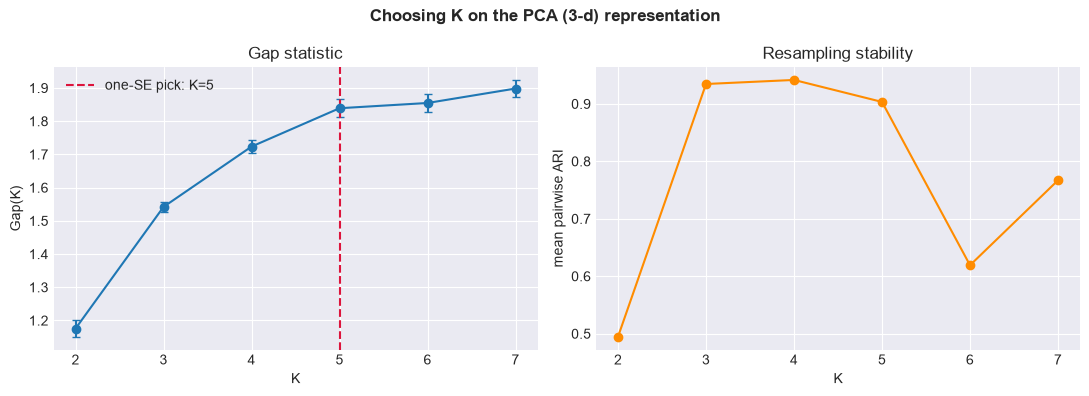

Gap statistic (one-SE rule): K=5.  Stability curve: K in [3, 4] tied (best 0.942).
K=5 chosen: methods disagree -- gap statistic is the deciding tool since it is validated against a null reference rather than only against itself; the stability curve disagreeing on this K is itself worth treating as LOWER CONFIDENCE in the pick, not something to silently override.


K-Means vs GMM agreement at K=5: ARI=0.341 (the two algorithms give meaningfully different partitions -- worth flagging in the report).
(Sanity check only, never used to build the pipeline: ARI against the TRUE segment labels = 0.311.)
Delivered K=5 partition's own silhouette: 0.3832 (distinct from Section 4's representation-choice silhouette, which was measured at a different K during that comparison).
CAVEAT: the delivered K=5 partition's smallest cluster (14 points) is itself below the 5% floor (30 points) used to screen REPRESENTATION choice in Section 4 -- that guard does not extend to this K-selection stage. This is the same anomaly-isolation phenomenon recurring: gap statistic and stability curve measure cluster SEPARATION, not minimum cluster SIZE, so a genuinely well-separated but tiny anomaly cluster can still win K-selection. Section 6 is what actually resolves these points.


In [5]:
def within_dispersion(X, labels, k):
    total = 0.0
    for c in range(k):
        pts = X[labels == c]
        if len(pts) > 1:
            centroid = pts.mean(axis=0)
            total += ((pts - centroid) ** 2).sum()
    return total


def gap_statistic(X, k_range, B=15, seed=SEED):
    """Adapted from 27A/27B (same PCA-aligned uniform reference and one-SE rule). B and n_init match
    27B's reduction from 27A's originals (B: 20->15, n_init: 10/5->5/3) for a single-representation
    sweep here rather than 27B's two-dataset panel -- a real behaviour change, stated rather than
    claimed as unchanged."""
    rng_local = np.random.default_rng(seed)
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    X_rot = Xc @ Vt.T
    box_min, box_max = X_rot.min(axis=0), X_rot.max(axis=0)
    gaps, sks = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=5, random_state=seed).fit(X)
        log_wk = np.log(within_dispersion(X, km.labels_, k))
        log_wk_refs = []
        for b in range(B):
            X_ref_rot = rng_local.uniform(box_min, box_max, size=X_rot.shape)
            X_ref = X_ref_rot @ Vt
            km_ref = KMeans(n_clusters=k, n_init=3, random_state=seed + b + 1).fit(X_ref)
            log_wk_refs.append(np.log(within_dispersion(X_ref, km_ref.labels_, k)))
        log_wk_refs = np.array(log_wk_refs)
        gaps.append(log_wk_refs.mean() - log_wk)
        sks.append(log_wk_refs.std(ddof=0) * np.sqrt(1 + 1 / B))
    return np.array(gaps), np.array(sks)


def one_se_k(k_range, gaps, sks):
    k_list = list(k_range)
    for i in range(len(k_list) - 1):
        if gaps[i] >= gaps[i + 1] - sks[i + 1]:
            return k_list[i]
    return k_list[-1]


def stability_curve(X, k_range, n_resamples=15, subsample_frac=0.8, seed=SEED):
    """Adapted from 27A/27B (same mean-pairwise-ARI-on-shared-points logic). Keeps 27A's
    n_resamples=15 default but adopts 27B's n_init=3 and mean-only return (no stds, since this
    single-representation sweep does not plot error bars) -- again a real change, stated rather
    than claimed as unchanged."""
    rng_local = np.random.default_rng(seed)
    n = X.shape[0]
    sub_n = int(n * subsample_frac)
    means = []
    for k in k_range:
        idx_sets, label_sets = [], []
        for r in range(n_resamples):
            idx = rng_local.choice(n, sub_n, replace=False)
            km = KMeans(n_clusters=k, n_init=3, random_state=seed + r).fit(X[idx])
            idx_sets.append(set(idx.tolist())); label_sets.append((idx, km.labels_))
        aris = []
        for a in range(n_resamples):
            for b in range(a + 1, n_resamples):
                idx_a, lab_a = label_sets[a]; idx_b, lab_b = label_sets[b]
                common = idx_sets[a] & idx_sets[b]
                if len(common) < k + 1:
                    continue
                common = np.array(sorted(common))
                pos_a = {v: i for i, v in enumerate(idx_a)}
                pos_b = {v: i for i, v in enumerate(idx_b)}
                la = [lab_a[pos_a[c]] for c in common]
                lb = [lab_b[pos_b[c]] for c in common]
                aris.append(adjusted_rand_score(la, lb))
        means.append(np.mean(aris) if aris else np.nan)
    return np.array(means)


K_RANGE = range(2, 8)
gaps, sks = gap_statistic(X_chosen, K_RANGE)
gap_k = one_se_k(K_RANGE, gaps, sks)
stabs = stability_curve(X_chosen, K_RANGE)
TOL_STAB = 0.02
best_stab = stabs[np.nanargmax(stabs)]
tied_stab_ks = [k for k, s in zip(K_RANGE, stabs) if best_stab - s <= TOL_STAB]
stab_pick = tied_stab_ks[0] if len(tied_stab_ks) == 1 else tied_stab_ks

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(list(K_RANGE), gaps, yerr=sks, marker='o', capsize=3)
axes[0].axvline(gap_k, ls='--', c='crimson', label=f'one-SE pick: K={gap_k}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Gap(K)'); axes[0].legend(); axes[0].set_title('Gap statistic')
axes[1].plot(list(K_RANGE), stabs, marker='o', color='darkorange')
axes[1].set_xlabel('K'); axes[1].set_ylabel('mean pairwise ARI'); axes[1].set_title('Resampling stability')
plt.suptitle(f'Choosing K on the {best_rep} representation', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Gap statistic (one-SE rule): K={gap_k}.  Stability curve: "
      f"{'K in ' + str(stab_pick) + ' tied' if isinstance(stab_pick, list) else 'K=' + str(stab_pick)} "
      f"(best {best_stab:.3f}).")
agree = (gap_k == stab_pick) or (isinstance(stab_pick, list) and gap_k in stab_pick)
K_CHOSEN = gap_k  # gap statistic is the deciding tool -- validated against a null reference,
                  # rather than only against itself; when it disagrees with stability, that
                  # disagreement is reported as a confidence caveat below, never silently overridden
print(f"K={K_CHOSEN} chosen: {'both methods agree' if agree else 'methods disagree -- gap statistic is the deciding tool since it is validated against a null reference rather than only against itself; the stability curve disagreeing on this K is itself worth treating as LOWER CONFIDENCE in the pick, not something to silently override'}.")

km_final = KMeans(n_clusters=K_CHOSEN, n_init=10, random_state=SEED).fit(X_chosen)
gmm_final = GaussianMixture(n_components=K_CHOSEN, n_init=5, random_state=SEED).fit(X_chosen)
ari_km_gmm = adjusted_rand_score(km_final.labels_, gmm_final.predict(X_chosen))
print(f"K-Means vs GMM agreement at K={K_CHOSEN}: ARI={ari_km_gmm:.3f} "
      f"({'high agreement between the two algorithms' if ari_km_gmm > 0.7 else 'the two algorithms give meaningfully different partitions -- worth flagging in the report'}).")

ari_vs_true = adjusted_rand_score(true_segment, km_final.labels_)
print(f"(Sanity check only, never used to build the pipeline: ARI against the TRUE segment labels = "
      f"{ari_vs_true:.3f}.)")

km_final_silhouette = silhouette_score(X_chosen, km_final.labels_)
print(f"Delivered K={K_CHOSEN} partition's own silhouette: {km_final_silhouette:.4f} "
      f"(distinct from Section 4's representation-choice silhouette, which was measured at a "
      f"different K during that comparison).")

# D3 -- the MIN_CLUSTER_FRAC guard in Section 4 only screened REPRESENTATION choice; it does not
# constrain this K-selection stage (gap+stability), so the delivered partition can still isolate a
# sub-floor cluster. Report this honestly rather than let it pass silently.
final_smallest = int(np.bincount(km_final.labels_).min())
final_floor = int(MIN_CLUSTER_FRAC * len(X_chosen))
if final_smallest < final_floor:
    print(f"CAVEAT: the delivered K={K_CHOSEN} partition's smallest cluster ({final_smallest} points) "
          f"is itself below the {MIN_CLUSTER_FRAC:.0%} floor ({final_floor} points) used to screen "
          f"REPRESENTATION choice in Section 4 -- that guard does not extend to this K-selection stage. "
          f"This is the same anomaly-isolation phenomenon recurring: gap statistic and stability curve "
          f"measure cluster SEPARATION, not minimum cluster SIZE, so a genuinely well-separated but tiny "
          f"anomaly cluster can still win K-selection. Section 6 is what actually resolves these points.")


<a name="anomalies"></a>
## Density and Anomalies: Two Methods, Compared

**Isolation Forest** (tree-based, isolates points by how few random splits it takes to separate them) and
**kernel density estimation** (Lesson 18, flags points in the lowest-density region directly) answer the
same question by unrelated mechanisms. Where they agree, that agreement is real evidence; where they
disagree, both lists are reported, not one silently preferred.

Isolation Forest flagged 18 of 600 customers (3.0%).
KDE (lowest 3% density) flagged 18 of 600 customers (3.0%).
BOTH methods flag 14 customers; EITHER method flags 22.

(Of the 18 TRUE injected anomalies, 14 are caught by BOTH methods and 18 by EITHER method -- 77.8% and 100.0% recall respectively; precision is 100.0% (both) and 81.8% (either). NOTE: contamination=0.03 and the KDE 0.03 density quantile were both set to match the KNOWN synthetic injection rate for this demonstration -- the true rate is not available in a real deployment, so these recall numbers benefit from a simplification flagged honestly in the written report's not-done list below, not a from-nothing discovery.)


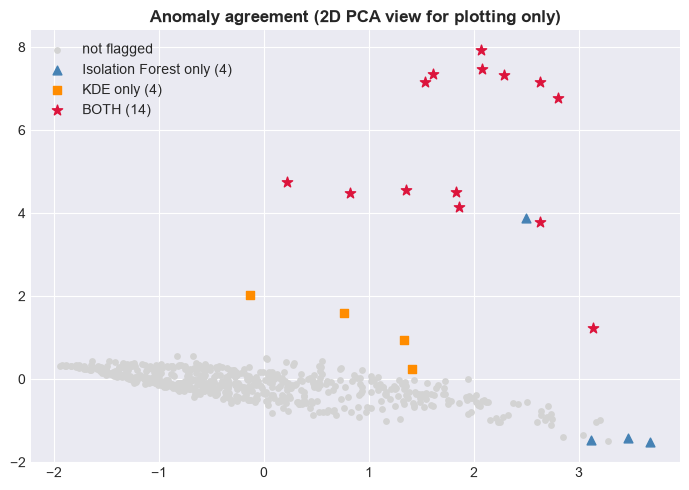

In [6]:
iso = IsolationForest(contamination=0.03, random_state=SEED).fit(X_chosen)
iso_flagged = iso.predict(X_chosen) == -1

kde = KernelDensity(bandwidth='scott').fit(X_chosen)
log_density = kde.score_samples(X_chosen)
density_threshold = np.quantile(log_density, 0.03)
kde_flagged = log_density < density_threshold

both_flagged = iso_flagged & kde_flagged
either_flagged = iso_flagged | kde_flagged
print(f"Isolation Forest flagged {iso_flagged.sum()} of {len(df)} customers ({iso_flagged.sum() / len(df):.1%}).")
print(f"KDE (lowest {0.03:.0%} density) flagged {kde_flagged.sum()} of {len(df)} customers ({kde_flagged.sum() / len(df):.1%}).")
print(f"BOTH methods flag {both_flagged.sum()} customers; EITHER method flags {either_flagged.sum()}.")

tp_both = (both_flagged & is_true_anomaly).sum()
tp_either = (either_flagged & is_true_anomaly).sum()
precision_both = tp_both / both_flagged.sum() if both_flagged.sum() else float('nan')
precision_either = tp_either / either_flagged.sum() if either_flagged.sum() else float('nan')
print(f"\n(Of the {N_ANOMALIES} TRUE injected anomalies, {tp_both} are caught by BOTH methods and "
      f"{tp_either} by EITHER method -- {tp_both / N_ANOMALIES:.1%} and {tp_either / N_ANOMALIES:.1%} "
      f"recall respectively; precision is {precision_both:.1%} (both) and {precision_either:.1%} "
      f"(either). NOTE: contamination=0.03 and the KDE 0.03 density quantile were both set to match "
      f"the KNOWN synthetic injection rate for this demonstration -- the true rate is not available in "
      f"a real deployment, so these recall numbers benefit from a simplification flagged honestly in "
      f"the written report's not-done list below, not a from-nothing discovery.)")

fig, ax = plt.subplots(figsize=(7, 5))
pca_viz = PCA(n_components=2, random_state=SEED).fit_transform(X_chosen)
ax.scatter(pca_viz[~either_flagged, 0], pca_viz[~either_flagged, 1], c='lightgrey', s=15, label='not flagged')
only_iso = iso_flagged & ~kde_flagged
only_kde = kde_flagged & ~iso_flagged
ax.scatter(pca_viz[only_iso, 0], pca_viz[only_iso, 1], c='steelblue', s=40, marker='^', label=f'Isolation Forest only ({only_iso.sum()})')
ax.scatter(pca_viz[only_kde, 0], pca_viz[only_kde, 1], c='darkorange', s=40, marker='s', label=f'KDE only ({only_kde.sum()})')
ax.scatter(pca_viz[both_flagged, 0], pca_viz[both_flagged, 1], c='crimson', s=60, marker='*', label=f'BOTH ({both_flagged.sum()})')
ax.legend(); ax.set_title('Anomaly agreement (2D PCA view for plotting only)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

<a name="report"></a>
## Interpretation and Written Report

In [7]:
print("=" * 88)
print("CAPSTONE REPORT: Customer Segmentation and Anomaly Review")
print("=" * 88)
print(f"\n1. SEGMENTATION")
alt_reps_prose = '; '.join(
    f"{n} {round(r[0], 3) if r[1] is not None else 'excluded (no non-degenerate K)'}"
    for n, r in rep_results.items() if n != best_rep
)
print(f"   K={K_CHOSEN} segments chosen on the '{best_rep}' representation "
      f"(representation picked for its guarded silhouette {rep_results[best_rep][0]:.3f} vs {alt_reps_prose}; "
      f"the delivered K={K_CHOSEN} partition's own silhouette is {km_final_silhouette:.4f}).")
print(f"   Confidence: gap statistic (one-SE) picks K={gap_k}; resampling stability "
      f"{'agrees' if agree else 'DIFFERS (LOWER CONFIDENCE -- gap statistic used as the decider, see Section 5 above)'}; "
      f"K-Means vs GMM agreement ARI={ari_km_gmm:.3f}; the delivered partition's smallest cluster is "
      f"{'below' if final_smallest < final_floor else 'above'} the {MIN_CLUSTER_FRAC:.0%} floor used to "
      f"screen representation choice (Section 4).")
seg_sizes = {int(k): int(v) for k, v in zip(*np.unique(km_final.labels_, return_counts=True))}
print(f"   Segment sizes: {seg_sizes}.")
smallest_cluster = int(np.argmin(np.bincount(km_final.labels_)))
smallest_size = int(np.bincount(km_final.labels_)[smallest_cluster])
print(f"   Cluster {smallest_cluster} ({smallest_size} customers, {smallest_size / len(df):.1%} of the "
      f"base) is small enough to be worth flagging as a possible anomaly-driven artifact rather than a "
      f"targetable segment on its own -- Section 6 above checks this directly.")

print(f"\n2. ANOMALIES")
print(f"   {both_flagged.sum()} customers flagged by BOTH Isolation Forest and KDE -- the recommended "
      f"manual-review list, since agreement across two unrelated mechanisms is stronger evidence than "
      f"either alone.")
print(f"   {either_flagged.sum() - both_flagged.sum()} additional customers flagged by only one method -- "
      f"worth a lighter-touch second-tier review, not the same priority as the {both_flagged.sum()} above.")
print(f"   Precision at recall: {precision_both:.1%} (both-flagged) / {precision_either:.1%} (either-flagged) -- "
      f"reported alongside recall since a review queue with limited capacity is a precision problem too, "
      f"not only a recall problem.")

print(f"\n3. DECISION LOG RECAP")
for d in decision_log:
    print(f"   [{d['step']}] {d['choice']}")

print(f"\n4. WHAT WAS NOT DONE, AND WHY")
print(f"   - Contrastive representation learning (Lesson 26): built on augmentation invariances that are "
      f"well-defined for images, not for a four-column tabular record; inventing a tabular augmentation "
      f"scheme would be new research, not a reuse of that lesson.")
print(f"   - Spectral clustering / DP-mixture / normalizing-flow density (Lessons 17, 22, 19): all "
      f"applicable in principle to this data; excluded here to keep the pipeline to two compared "
      f"candidates per section rather than an exhaustive sweep, per this task's own scope.")
print(f"   - A held-out TEST set with true labels: this is a genuinely unsupervised problem in production "
      f"(no confirmed segment or fraud labels exist); the true labels used above are a validation "
      f"convenience of this teaching notebook, never available in the real deployment this capstone "
      f"describes.")
print(f"   - Hyperparameter tuning beyond what is shown: contamination=0.03 and the KDE density quantile "
      f"were set to match the synthetic anomaly rate for this demonstration; a real deployment would tune "
      f"these against the actual cost of a missed anomaly vs a wasted review.")

CAPSTONE REPORT: Customer Segmentation and Anomaly Review

1. SEGMENTATION
   K=5 segments chosen on the 'PCA (3-d)' representation (representation picked for its guarded silhouette 0.426 vs raw 0.324; autoencoder (3-d) excluded (no non-degenerate K); the delivered K=5 partition's own silhouette is 0.3832).
   Confidence: gap statistic (one-SE) picks K=5; resampling stability DIFFERS (LOWER CONFIDENCE -- gap statistic used as the decider, see Section 5 above); K-Means vs GMM agreement ARI=0.341; the delivered partition's smallest cluster is below the 5% floor used to screen representation choice (Section 4).
   Segment sizes: {0: 221, 1: 14, 2: 160, 3: 85, 4: 120}.
   Cluster 1 (14 customers, 2.3% of the base) is small enough to be worth flagging as a possible anomaly-driven artifact rather than a targetable segment on its own -- Section 6 above checks this directly.

2. ANOMALIES
   14 customers flagged by BOTH Isolation Forest and KDE -- the recommended manual-review list, since agre

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **A capstone is a sequence of justified choices, not a sequence of default choices.** Every step above
   -- imputation strategy, encoding, representation, K, anomaly threshold -- was compared against at
   least one alternative with a measured number, not picked because it is the first tool that comes to
   mind.
2. **A representation-choice metric needs a floor against degenerate splits, and even a guarded metric
   can still mislead.** A bare highest-silhouette-at-any-K search rewards a representation for isolating
   a handful of extreme-spend points as their own tiny "segment"; guarding against that (Section 4) is
   necessary. But Section 4 also caught a SECOND blind spot: raw and PCA's guarded winners at K=2 turned
   out to be the IDENTICAL partition (ARI=1.000) scored differently only because silhouette depends on
   the space it is measured in -- so "PCA scored higher" did not mean "PCA found better structure" here.
   Representation choice was still made (PCA, for its lower dimensionality), just not on the grounds the
   silhouette number alone would suggest.
3. **K was chosen the way Lesson 27 argues it should be** -- a gap statistic validated against a null
   reference, plus a resampling stability curve, cross-checked against a second clustering algorithm
   (GMM), not a single silhouette number treated as final.
4. **Anomaly detection by two mechanistically unrelated methods (isolation, density) gives a natural
   confidence tier**: agreement is the priority list, disagreement is a secondary list, neither is
   discarded.
5. **The mandatory honesty section is not a formality** -- naming what was excluded (contrastive learning,
   three other clustering families, hyperparameter tuning) and WHY is exactly the discipline that
   distinguishes this capstone's report from a black-box output.
6. **The same near-empty anomaly-isolating cluster showed up at every K tested on the autoencoder
   representation, and from K=3 upward on raw and PCA** (Section 4's own guarded-search output) -- not
   a quirk of one method, but K-Means' well-documented sensitivity to extreme outliers reasserting
   itself across representations; the pipeline's own anomaly-detection section (6) is what actually
   resolves those points, not a lucky choice of K or embedding. It recurred again in Section 5's own K=5
   pick (see Section 5's CAVEAT print), since the guard applied to representation choice does not
   extend to gap-statistic/stability K-selection.

### Practical Guidance

- Fit every preprocessing statistic (scaler, imputer, encoder) on a fit-only split, even in a fully
  unsupervised pipeline with no labels to hold out for -- the leakage risk is about the STATISTICS, not
  about labels.
- Compare representations on a downstream task's own metric (here, clustering silhouette), not on an
  unrelated proxy like reconstruction error alone -- and guard that metric against rewarding a
  degenerate split (a tiny outlier-only cluster scores well without finding real structure).
- Report a confidence number alongside K and alongside every anomaly list, never K or a flagged-point
  count in isolation.
- Write the not-done-and-why list before the report feels finished, not after -- it is where the honest
  limits of the analysis actually live.

### What This Lesson Did Not Cover

- A held-out true test set with real labels (this is a synthetic capstone; the true segments and
  anomalies exist only to validate the pipeline's own conclusions, never to train it).
- Model deployment, monitoring or drift detection once a segmentation or anomaly threshold ships to
  production -- a real next step, out of scope for a single analysis notebook.
- The three methods named but not built in the Report section above (contrastive tabular representations,
  spectral/DP-mixture clustering, normalizing-flow density) -- each a legitimate alternative, excluded here
  to keep this capstone's comparisons to two candidates per section.

### Next Steps

This closes Part II of Unsupervised Learning. The course's full toolkit -- from Part I's foundational
methods through Part II's representation learning, self-supervision and honestly-reported clustering
confidence -- has now been exercised together, once, end to end, on one problem.